# Задание 6: Вычисление P^k и предельное распределение

Проверяем сходимость матрицы переходов к стационарному распределению.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Bio import SeqIO

## Матрица переходов P из задания 5

In [2]:
nucleotides = ['A', 'C', 'G', 'T']
nuc_index = {'A': 0, 'C': 1, 'G': 2, 'T': 3}

record = next(SeqIO.parse("GCA_029856635.1_ASM2985663v1_genomic.fna", "fasta"))
seq = ''.join(c for c in str(record.seq).upper() if c in 'ACGT')

dinuc_counts = np.zeros((4, 4), dtype=int)
for i in range(len(seq) - 1):
    dinuc_counts[nuc_index[seq[i]], nuc_index[seq[i+1]]] += 1

P = dinuc_counts / dinuc_counts.sum(axis=1, keepdims=True)


## 1–2. Возводим P в степени k = 2, 5, 10, 50, 100, 1000

In [3]:
for k in [2, 5, 10, 50, 100, 1000]:
    P_k = np.linalg.matrix_power(P, k)
    print(f"\nP^{k}:")
    print("     ", "       ".join(nucleotides))
    for i, nuc in enumerate(nucleotides):
        print(f"{nuc}  ", [round(x, 6) for x in P_k[i]])


P^2:
      A       C       G       T
A   [np.float64(0.320788), np.float64(0.175601), np.float64(0.177261), np.float64(0.326351)]
C   [np.float64(0.314657), np.float64(0.177712), np.float64(0.176103), np.float64(0.331529)]
G   [np.float64(0.324689), np.float64(0.175174), np.float64(0.174843), np.float64(0.325294)]
T   [np.float64(0.309501), np.float64(0.18297), np.float64(0.175637), np.float64(0.331891)]

P^5:
      A       C       G       T
A   [np.float64(0.316674), np.float64(0.178323), np.float64(0.176095), np.float64(0.328907)]
C   [np.float64(0.316667), np.float64(0.178327), np.float64(0.176094), np.float64(0.328912)]
G   [np.float64(0.316675), np.float64(0.178323), np.float64(0.176095), np.float64(0.328906)]
T   [np.float64(0.316662), np.float64(0.17833), np.float64(0.176094), np.float64(0.328914)]

P^10:
      A       C       G       T
A   [np.float64(0.316669), np.float64(0.178326), np.float64(0.176095), np.float64(0.32891)]
C   [np.float64(0.316669), np.float64(0.178326), np

## 3. График стабилизации матрицы

По оси Y — норма Фробениуса $\|P^k - P^{k-1}\|_F$.

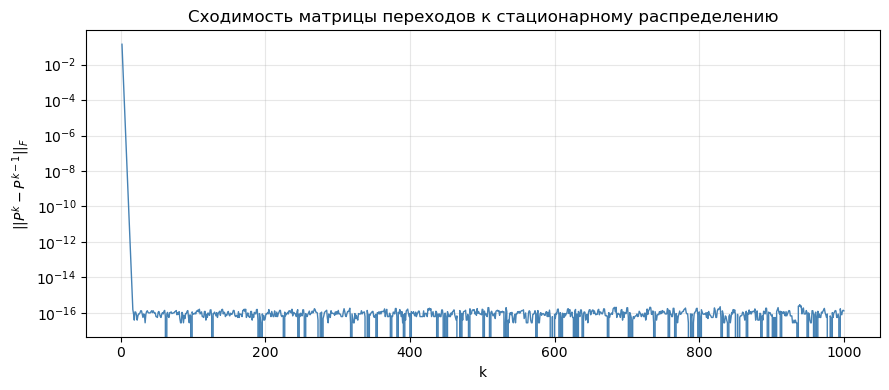

In [4]:
K_MAX = 1000
norms = []
P_prev = P.copy()

for k in range(2, K_MAX + 1):
    P_k = np.linalg.matrix_power(P, k)
    norm = np.linalg.norm(P_k - P_prev, 'fro')
    norms.append(norm)
    P_prev = P_k

ks = list(range(2, K_MAX + 1))

plt.figure(figsize=(9, 4))
plt.plot(ks, norms, color='steelblue', linewidth=1)
plt.xlabel("k")
plt.ylabel(r"$||P^k - P^{k-1}||_F$")
plt.title("Сходимость матрицы переходов к стационарному распределению")
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("markov_convergence.png", dpi=150)
plt.show()

## 4. P^1000 — проверка сходимости к π

In [5]:
P_1000 = np.linalg.matrix_power(P, 1000)

print("P^1000:")
print("     ", "       ".join(nucleotides))
for i, nuc in enumerate(nucleotides):
    print(f"{nuc}  ", [round(x, 6) for x in P_1000[i]])

# Стационарное распределение
eigenvalues, eigenvectors = np.linalg.eig(P.T)
idx = np.argmax(np.real(eigenvalues))
pi = np.real(eigenvectors[:, idx])
pi = pi / pi.sum()

print("\nСтационарное распределение π:")
for nuc, p in zip(nucleotides, pi):
    print(f"  π({nuc}) = {p:.6f}")

print("\nВывод: при k = 1000 все строки P^k одинаковы и совпадают с π — цепь сошлась.")

P^1000:
      A       C       G       T
A   [np.float64(0.316669), np.float64(0.178326), np.float64(0.176095), np.float64(0.32891)]
C   [np.float64(0.316669), np.float64(0.178326), np.float64(0.176095), np.float64(0.32891)]
G   [np.float64(0.316669), np.float64(0.178326), np.float64(0.176095), np.float64(0.32891)]
T   [np.float64(0.316669), np.float64(0.178326), np.float64(0.176095), np.float64(0.32891)]

Стационарное распределение π:
  π(A) = 0.316669
  π(C) = 0.178326
  π(G) = 0.176095
  π(T) = 0.328910

Вывод: при k = 1000 все строки P^k одинаковы и совпадают с π — цепь сошлась.
